# Testing EI-RNN Initialization for CTDS

Compare EM convergence and parameter recovery between:
1. **Random init** — default `CTDS` initialization
2. **EI-RNN init** — data-driven initialization via constrained regression + NMF

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation.ctds_inherit import CTDS
from pillow_lab_rotation.simulate import CTDSSim, generate_pulsatile_inputs

plt.style.use('../Js.mplstyle')

## Simulate ground-truth CTDS data

In [ ]:
Ne, Ni = 15, 15
De, Di = 5, 5
udim = 3
n_trials = 100
T = 100

np.random.seed(0)
sim = CTDSSim(De, Di, Ne, Ni, udim=udim)
sim.create_params()
A_true, C_true, Q_true, Q0_true, mu0_true, R_true, B_true = sim.get_params()

U_all = generate_pulsatile_inputs(n_trials, T, udim)
X_all, Y_all = sim.simulate(T, n_trials, inputs=U_all)
print(f"Observations shape: {Y_all.shape}")
print(f"Inputs shape: {U_all.shape}")
print(f"A spectral radius: {np.max(np.abs(np.linalg.eigvals(A_true))):.3f}")

## Fit with random initialization

In [ ]:
np.random.seed(0)
ctds_random = CTDS(De, Di, Ne, Ni, udim=udim)
ctds_random.init_params()  # random init (no observations)
ctds_random.fit(Y_all, inputs=U_all, verbose=True, criterion=1e-6)

## Fit with EI-RNN initialization

In [ ]:
np.random.seed(0)
ctds_eirnn = CTDS(De, Di, Ne, Ni, udim=udim)
ctds_eirnn.init_params(observations=Y_all, start_seed=0)  # EI-RNN init
ctds_eirnn.fit(Y_all, inputs=U_all, verbose=True, criterion=1e-6)

## Compare log-likelihood convergence

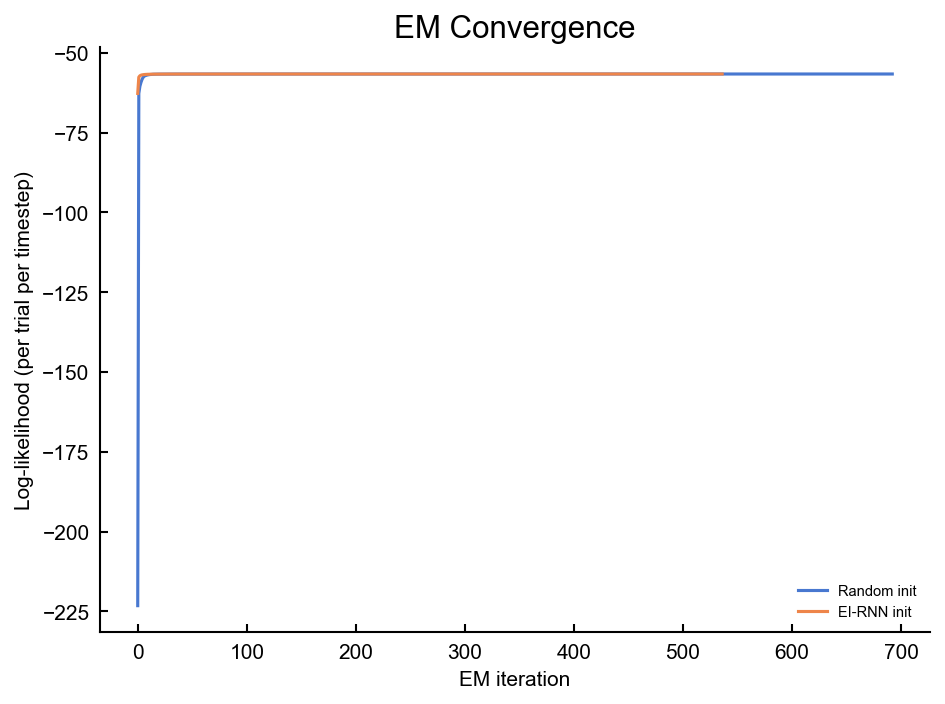

In [8]:
fig, ax = plt.subplots()
ax.plot(ctds_random.ll_history, label='Random init')
ax.plot(ctds_eirnn.ll_history, label='EI-RNN init')
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood (per trial per timestep)')
ax.legend()
ax.set_title('EM Convergence')
# ax.set_xscale('log')
# ax.set_yscale('log')
fig.tight_layout()

## Parameter recovery (aligned via Procrustes-style matching)

Since the latent space is only identifiable up to an invertible linear transform, we align recovered parameters to ground truth via $H = (C'^T C')^{-1} C'^T C_{\text{true}}$.

In [ ]:
def align_params(ctds_fit):
    """Align recovered params to ground truth via C-based linear transform."""
    C_fit = ctds_fit.C
    H = np.linalg.inv(C_fit.T @ C_fit) @ C_fit.T @ C_true
    H_inv = np.linalg.inv(H)
    A_aligned = H_inv @ ctds_fit.A @ H
    C_aligned = C_fit @ H
    Q_aligned = H_inv @ ctds_fit.Q @ H_inv.T
    B_aligned = H_inv @ ctds_fit.B
    return A_aligned, C_aligned, Q_aligned, ctds_fit.R, B_aligned

def param_mses(ctds_fit):
    A_al, C_al, Q_al, R_fit, B_al = align_params(ctds_fit)
    return {
        'A': np.mean((A_al - A_true)**2),
        'C': np.mean((C_al - C_true)**2),
        'Q': np.mean((Q_al - Q_true)**2),
        'R': np.mean((R_fit - R_true)**2),
        'B': np.mean((B_al - B_true)**2),
    }

mse_random = param_mses(ctds_random)
mse_eirnn = param_mses(ctds_eirnn)

print(f"{'Param':<6} {'Random init':>14} {'EI-RNN init':>14}")
print("-" * 36)
for key in mse_random:
    print(f"{key:<6} {mse_random[key]:>14.6f} {mse_eirnn[key]:>14.6f}")

## Visual comparison of recovered matrices

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9))

A_rand, C_rand, Q_rand, R_rand, B_rand = align_params(ctds_random)
A_ei, C_ei, Q_ei, R_ei, B_ei = align_params(ctds_eirnn)

rows = [
    ('A', A_true, A_rand, A_ei),
    ('C', C_true, C_rand, C_ei),
    ('B', B_true, B_rand, B_ei),
]

for row_axes, (name, true, rand, ei) in zip(axes, rows):
    titles = [f'{name} (true)', f'{name} (random)', f'{name} (EI-RNN)', f'{name} (diff EI-RNN)']
    mats = [true, rand, ei, ei - true]
    for ax, title, mat in zip(row_axes, titles, mats):
        vmax = max(np.abs(true).max(), np.abs(mat).max())
        ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Aligned parameter recovery (with inputs)')
fig.tight_layout()